In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
early_twenties = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/stability_summary_20_25.csv')
late_twenties = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/stability_summary_25_30.csv')
early_thirties = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/stability_summary_30_35.csv')

In [4]:
# define wanted window
df = early_twenties

In [6]:
stable_95 = df[~df['stable_n_95'].isnull()]['roi'].tolist()
stable_99 = df[~df['stable_n_99'].isnull()]['roi'].tolist()

print(f"rois that stabilized for 95% CI: {stable_95}")
print(f"rois that stabilized for 99% CI: {stable_99}")

# save the list of 95% stable rois to load to step10

import json

# Load from the same directory
with open("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/stable_95_early_twenties.json", "w") as f: #CHANGE ACCORDING TO AGE BIN
    json.dump(stable_95, f)
print(f"Saved {len(stable_95)} ROIs to JSON.")# Example: print(roi_list_95[:5])

rois that stabilized for 95% CI: [32, 33, 35, 39, 40, 65, 92, 98, 99, 100, 102, 103, 104, 105, 107, 113, 143, 152, 155, 169, 193, 198, 231, 233, 234, 235, 237, 239, 240, 241, 242, 243, 268, 269, 270, 293, 302, 303, 304, 305, 306, 307, 308, 309, 311, 312, 318, 340, 360, 391, 393, 414, 416, 418, 421, 422, 423, 441, 443, 445, 449]
rois that stabilized for 99% CI: [32, 35, 92, 98, 99, 100, 102, 104, 143, 152, 169, 193, 234, 235, 237, 239, 243, 268, 270, 302, 303, 304, 305, 306, 308, 309, 311, 318, 360, 414, 421, 441, 443]
Saved 61 ROIs to JSON.


# Visualizations

## Funnel Plot

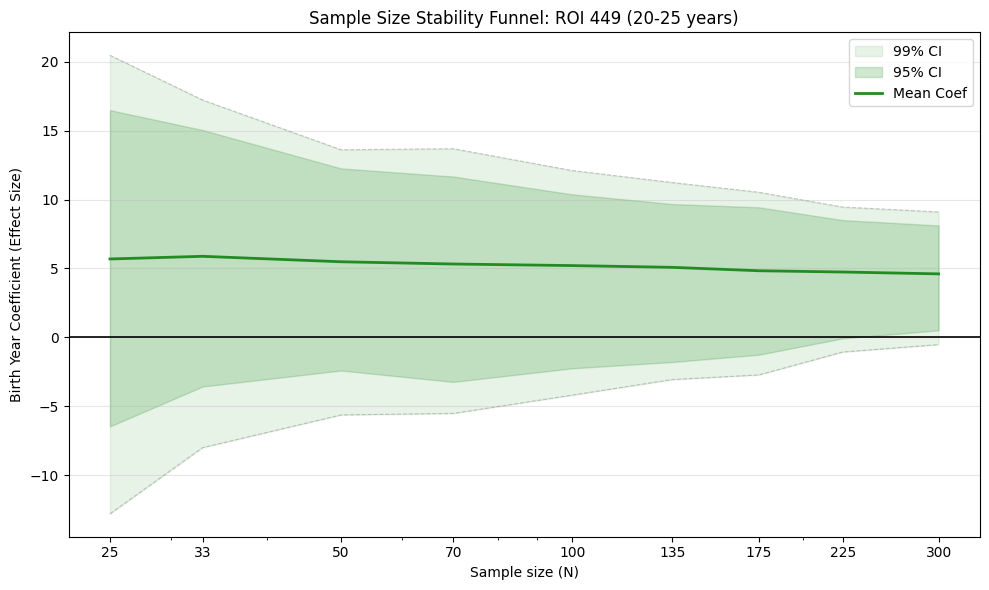

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the stats data generated by your simulation
# (Ensure your save script included 'roi' and 'age_bin' columns)
stats_path = "/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/plotting_stats_20_25.csv"
stats_df = pd.read_csv(stats_path)

def plot_funnel(df, roi_id, age_label, n_list):
    """
    Generates a funnel plot for a specific ROI from pre-calculated stats.
    """
    roi_data = df[df['roi'] == roi_id]
    
    if roi_data.empty:
        print(f"No data found for ROI {roi_id}")
        return

    plt.figure(figsize=(10, 6))

    # --- Shading Layers ---
    plt.fill_between(roi_data['sample_size'], roi_data['low_99'], roi_data['high_99'], 
                     color='forestgreen', alpha=0.1, label='99% CI')
    plt.fill_between(roi_data['sample_size'], roi_data['low_95'], roi_data['high_95'], 
                     color='forestgreen', alpha=0.2, label='95% CI')

    # --- Border Lines ---
    plt.plot(roi_data['sample_size'], roi_data['low_99'], color='gray', linestyle='--', lw=0.8, alpha=0.4)
    plt.plot(roi_data['sample_size'], roi_data['high_99'], color='gray', linestyle='--', lw=0.8, alpha=0.4)

    # --- Central Trend ---
    plt.plot(roi_data['sample_size'], roi_data['mean'], color='forestgreen', lw=2, label='Mean Coef')

    # Formatting
    plt.xscale('log')
    plt.xticks(n_list, labels=[str(x) for x in n_list])
    plt.axhline(0, color='black', lw=1.2)
    plt.grid(axis='y', alpha=0.3)
    
    plt.xlabel('Sample size (N)')
    plt.ylabel('Birth Year Coefficient (Effect Size)')
    plt.title(f'Sample Size Stability Funnel: ROI {roi_id} ({age_label} years)')
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
N_LIST = [25, 33, 50, 70, 100, 135, 175, 225, 300]
TARGET_ROI = 449 # Change this to view different regions

plot_funnel(stats_df, TARGET_ROI, "20-25", N_LIST)

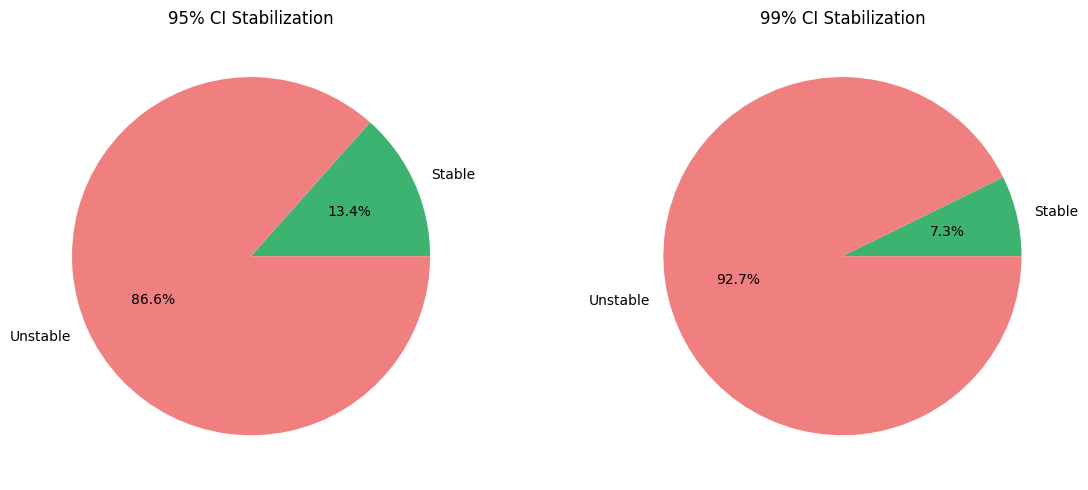

In [9]:
# pie chart of null vs non-null for 95% and 99% CI stabilization
stable_95_count = df['stable_n_95'].notnull().sum()
unstable_95_count = df['stable_n_95'].isnull().sum()
stable_99_count = df['stable_n_99'].notnull().sum()
unstable_99_count = df['stable_n_99'].isnull().sum()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.pie([stable_95_count, unstable_95_count], labels=['Stable', 'Unstable'], autopct='%1.1f%%', colors=['mediumseagreen', 'lightcoral'])
plt.title('95% CI Stabilization')
plt.subplot(1, 2, 2)
plt.pie([stable_99_count, unstable_99_count], labels=['Stable', 'Unstable'], autopct='%1.1f%%', colors=['mediumseagreen', 'lightcoral'])
plt.title('99% CI Stabilization')
plt.tight_layout()
plt.show()

minimal sample size for 99% CI: 135.0
minimal sample size for 95% CI: 70.0


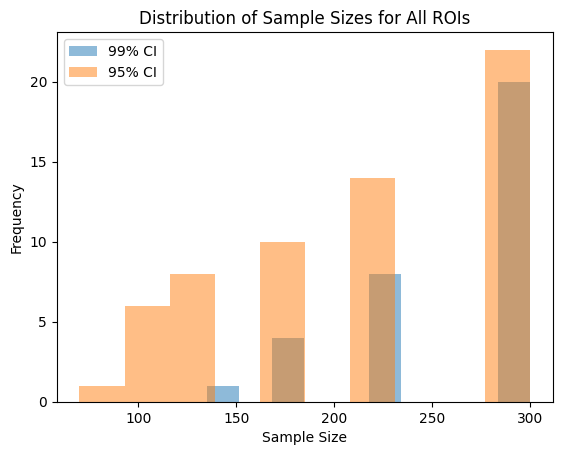

In [10]:
print(f"minimal sample size for 99% CI: {df['stable_n_99'].min()}")
print(f"minimal sample size for 95% CI: {df['stable_n_95'].min()}")

# plot a histogram of stable_n_99 and stable_n_95 for all rois
plt.hist(df['stable_n_99'], alpha=0.5, label='99% CI')
plt.hist(df['stable_n_95'], alpha=0.5, label='95% CI')
plt.xlabel('Sample Size')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Sizes for All ROIs')
plt.legend()
plt.show()